Step 0: Install requirements

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import pandas as pd
import imutils
import dlib
import random

from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Dropout, Flatten, Dense, MaxPool2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.regularizers import l2
from imutils.face_utils import FaceAligner
from imutils.face_utils import rect_to_bb


Step 1: Upload Dataset to Google Drive

1452
1452
['Closed' 'Open']


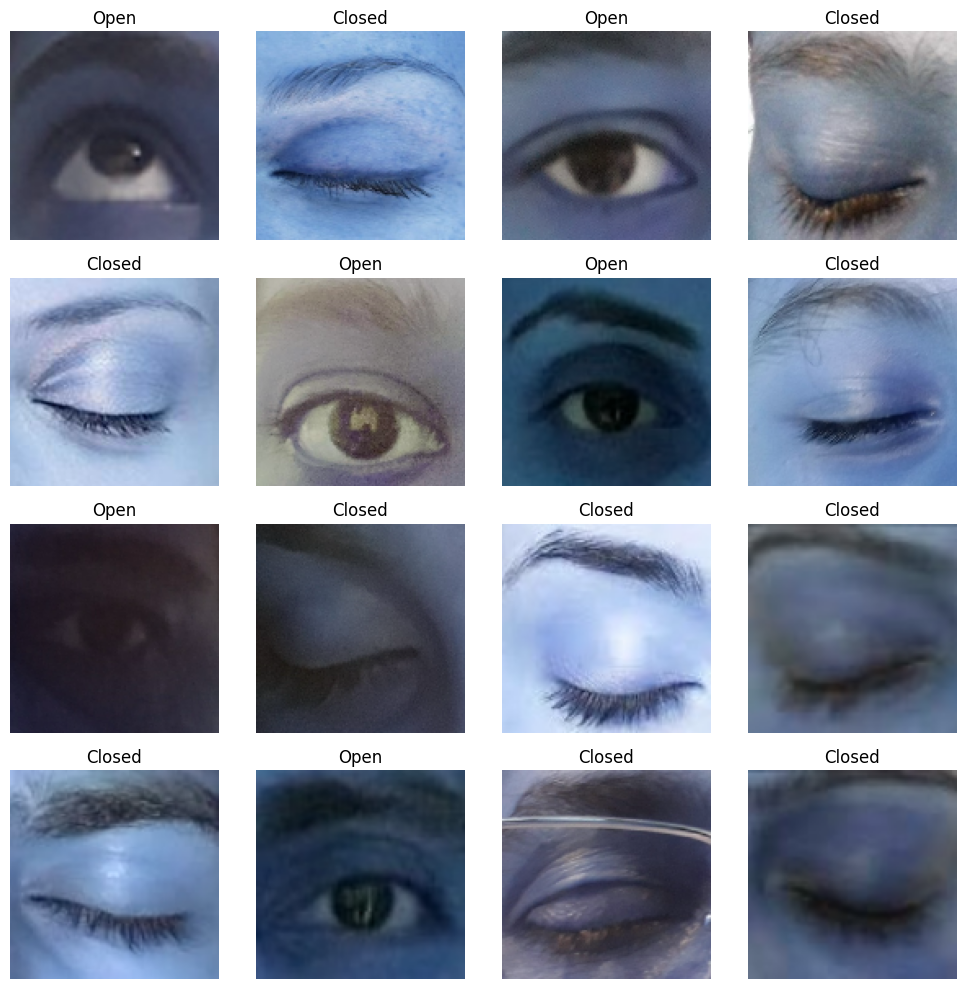

In [ ]:
data = np.load('/content/drive/MyDrive/driver_drowsiness_detection/dataset_compressed.npz', allow_pickle=True)
X = data['arr_0']
Y = data['arr_1']

X = list(X)
Y = list(Y)
print(len(X))
print(len(Y))

print(np.unique(Y))
plt.figure(figsize=(10, 10))
for i in range(16):
    idx = random.randint(0, len(X) - 1)
    img = X[idx]
    label = Y[idx]

    plt.subplot(4, 4, i + 1)
    if img.ndim == 2:  # grayscale
        plt.imshow(img, cmap='gray')
    else:              # RGB
        plt.imshow(img)
    plt.title(str(label))
    plt.axis('off')

plt.tight_layout()
plt.show()



Step 2: Data Preprocessing

In [ ]:
label_encoder = LabelEncoder()
Y = label_encoder.fit_transform(Y)
print(Y.shape)
print(set(Y))

unique_classes, counts = np.unique(Y, return_counts=True)
for cls, count in zip(unique_classes, counts):
    label = label_encoder.inverse_transform([cls])[0] # Decode the label back to original string
    print(f"Number of images for '{label}': {count}")

(1452,)
{np.int64(0), np.int64(1)}
Number of images for 'Closed': 726
Number of images for 'Open': 726


In [ ]:
for i in range(len(X)):
    img = X[i]
    img = cv2.resize(img, (32, 32))
    X[i] = img

print(len(X))
print(X[0].shape)

1452
(32, 32, 3)


In [ ]:
label_encoder = LabelEncoder()
Y = label_encoder.fit_transform(Y)
print(Y.shape)
print(Y[0])
print(set(Y))

(1452,)
0
{np.int64(0), np.int64(1)}


In [ ]:
X = np.array(X)
Y = np.array(Y)
print(X.shape)
print(Y.shape)

(1452, 32, 32, 3)
(1452,)


Delete not face image

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Train set size: 1161
Test set size: 291


In [ ]:
print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
Y_train = to_categorical(Y_train)
Y_test = to_categorical(Y_test)

print("Y_train shape after one-hot encoding:", Y_train.shape)
print("Y_test shape after one-hot encoding:", Y_test.shape)

Train set size: 1161
Test set size: 291
Y_train shape after one-hot encoding: (1161, 2)
Y_test shape after one-hot encoding: (291, 2)


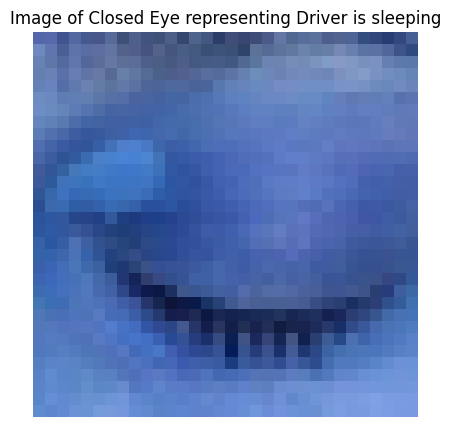

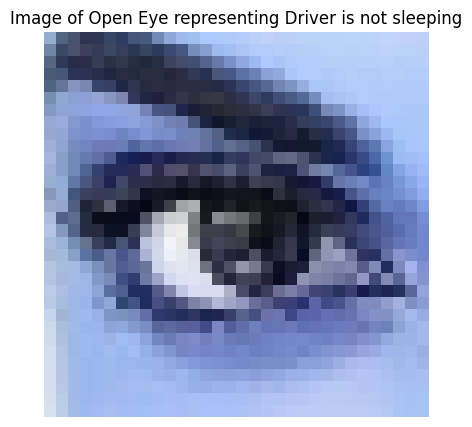

In [ ]:
figure1 = plt.figure(figsize=(5, 5))
idx_closed = np.where(Y==0)
img_closed = X[idx_closed[0][1]]
plt.imshow(img_closed)
plt.title('Image of Closed Eye representing Driver is sleeping')
plt.axis('off')
plt.show()

figure2 = plt.figure(figsize=(5, 5))
idx_open = np.where(Y==1)
img_open = X[idx_open[0][1]]
plt.imshow(img_open)
plt.title('Image of Open Eye representing Driver is not sleeping')
plt.axis('off')
plt.show()

In [ ]:
def driver_drowsiness_model(input_shape=(32, 32, 3)):
    model = Sequential()
    model.add(Input(shape=input_shape))

    filters = [16, 32, 64]
    for f in filters:
        model.add(Conv2D(f, (3, 3), padding='same', activation='relu'))
        model.add(BatchNormalization())
        model.add(MaxPool2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.4))  # Moderate dropout to prevent overfitting

    model.add(Dense(2, activation='softmax'))

    optimizer = Adam(learning_rate=0.01)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    return model
model= driver_drowsiness_model(input_shape=(32, 32, 3))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,762 (350.63 KB)

 Trainable params: 89,538 (349.76 KB)

 Non-trainable params: 224 (896.00 B)

In [ ]:
aug = ImageDataGenerator(rotation_range=20, zoom_range=0.2, horizontal_flip=True)
hist = model.fit(aug.flow(X_train, Y_train, batch_size=128), batch_size=16, epochs=20, validation_data=(X_test, Y_test))

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 528ms/step - accuracy: 0.6901 - loss: 1.5186 - val_accuracy: 0.5189 - val_loss: 16.8880
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step - accuracy: 0.8632 - loss: 0.3965 - val_accuracy: 0.5464 - val_loss: 9.1789
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 223ms/step - accuracy: 0.9238 - loss: 0.2281 - val_accuracy: 0.8316 - val_loss: 1.4639
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - accuracy: 0.9415 - loss: 0.1676 - val_accuracy: 0.8454 - val_loss: 0.7637
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - accuracy: 0.9456 - loss: 0.1481 - val_accuracy: 0.9416 - val_loss: 0.1795
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 287ms/step - accuracy: 0.9490 - loss: 0.1348 - val_accuracy: 0.9313 - val_loss: 0.2947
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step - accuracy: 0.9646 - loss: 0.0975 - val_accuracy: 0.9072 - val_loss: 0.4208
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/step - accuracy: 0.9614 - loss: 0.0845 - val_accuracy: 0.9416 - val

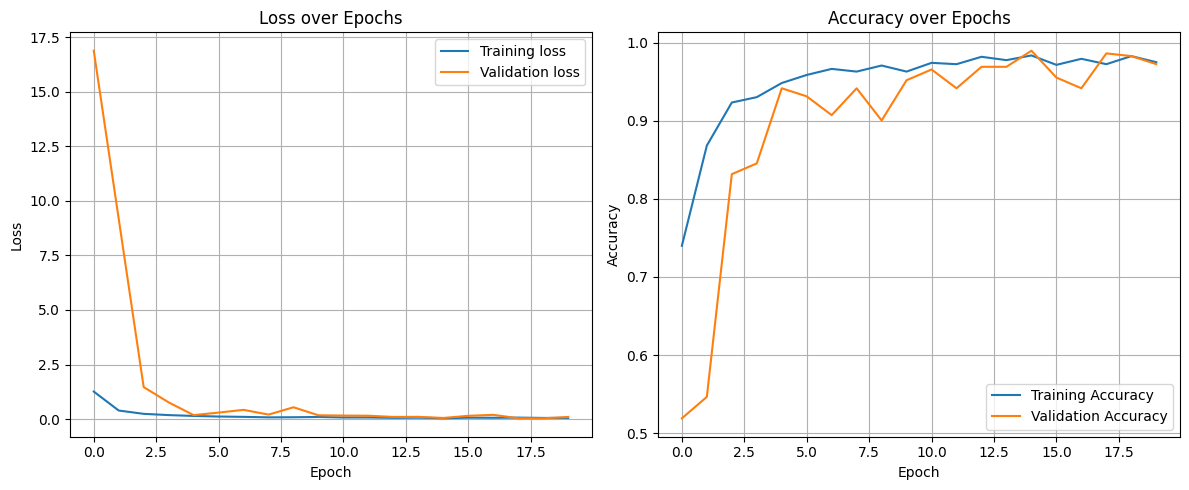

Training loss: 8.43%
Testing loss: 9.48%
Training accuracy: 97.33%
Testing accuracy: 97.25%


In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(hist.history['loss'], label='Training loss')
plt.plot(hist.history['val_loss'], label='Validation loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(hist.history['accuracy'], label='Training Accuracy')
plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

train_loss, train_accuracy = model.evaluate(X_train, Y_train, verbose=0)
test_loss, test_accuracy = model.evaluate(X_test, Y_test, verbose=0)

print(f"Training loss: {train_loss * 100:.2f}%")
print(f"Testing loss: {test_loss * 100:.2f}%")

print(f"Training accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing accuracy: {test_accuracy * 100:.2f}%")

In [ ]:
y_pred_prob = model.predict(X_test) #get predicted probabilities
y_pred_class = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to class labels (0 or 1)

# Convert Y_test and y_pred_class back to single-label format
Y_test_single_label = np.argmax(Y_test, axis=1)
y_pred_class_single_label = np.argmax(y_pred_class, axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


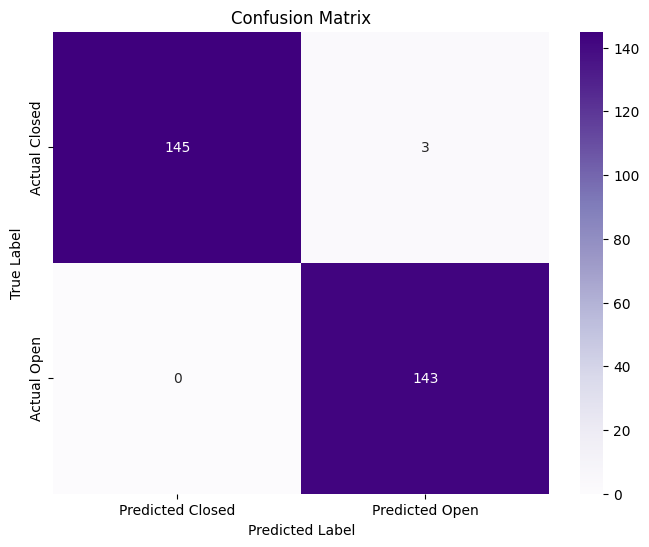

In [ ]:
cm = confusion_matrix(Y_test_single_label, y_pred_class_single_label)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Predicted Closed', 'Predicted Open'],
    yticklabels=['Actual Closed', 'Actual Open']
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
model.save('Driver_Drowsiness_Detection.h5')

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('Driver_Drowsiness_Detection.tflite', 'wb') as f:
    f.write(tflite_model)

print("Model converted to TFLite format and saved as 'Driver_Drowsiness_Detection.tflite'")

Saved artifact at '/tmp/tmphnrg2g34'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor_276')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  136239958834832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136239855180816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136239855178704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136239855181392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136239855179664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136239855180048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136239855179856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136239855180240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136239855180624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136239855182544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136239855181

In [ ]:
def check_available(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Image not found: {image_path}")
        return None
    return image

def full_face_detection_pipeline(input_image_path):
    eye_cascade = cv2.CascadeClassifier('/content/drive/MyDrive/driver_drowsiness_detection/haarcascade_eye.xml')
    detector = dlib.get_frontal_face_detector()
    predictor = dlib.shape_predictor('/content/drive/MyDrive/driver_drowsiness_detection/shape_predictor_68_face_landmarks.dat')

    # Load the TFLite model
    interpreter = tf.lite.Interpreter(model_path='/content/Driver_Drowsiness_Detection.tflite')
    interpreter.allocate_tensors()

    # Get input and output tensors.
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    output_path = '/content/drive/MyDrive/driver_drowsiness_detection/test_image_prediction.jpg'

    test_image = check_available(input_image_path)
    rects = detector(test_image, 2)

    faceAligned_gray = None
    avg_confidence = None
    detected_eyes = []

    if len(rects) == 0:
        print("No faces detected in the image.")
        cv2.imwrite(output_path, test_image)
        return output_path, faceAligned_gray, avg_confidence, detected_eyes

    for rect in rects:
        (x, y, w, h) = rect_to_bb(rect)
        faceAligned = test_image[y:y+h, x:x+w].copy()
        faceAligned_gray = cv2.cvtColor(faceAligned, cv2.COLOR_BGR2GRAY)

        eyes = eye_cascade.detectMultiScale(faceAligned_gray, 1.1, 6)
        predictions = []
        confidences = []
        for (ex, ey, ew, eh) in eyes:
            eye = faceAligned[ey:ey+eh, ex:ex+ew]
            detected_eyes.append(cv2.resize(eye, (32, 32))) # Store resized eye
            eye = cv2.resize(eye, (32, 32))
            eye = np.expand_dims(np.array(eye), axis=0).astype(np.float32) # Convert to float32

            # Set the tensor to the input data.
            interpreter.set_tensor(input_details[0]['index'], eye)

            # Run inference.
            interpreter.invoke()

            # Post-processing: get the output tensor
            output_data = interpreter.get_tensor(output_details[0]['index'])
            ypred_prob = output_data[0]

            ypred = np.argmax(ypred_prob)
            predictions.append(ypred)
            confidences.append(np.max(ypred_prob))

        # Decide label and color
        if all(pred == 0 for pred in predictions):
            label = "Sleepy"
            color = (0, 0, 255)  # Red
        else:
            label = "Not Sleeping"
            color = (0, 255, 0)  # Green

        # Draw rectangle and label
        cv2.rectangle(test_image, (x, y), (x+w, y+h), color, 8)
        cv2.putText(test_image, label, (x, y-10),
              cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 3)
        avg_confidence = np.mean(confidences) if confidences else 0


    cv2.imwrite(output_path, test_image)
    return output_path, faceAligned_gray, avg_confidence, detected_eyes

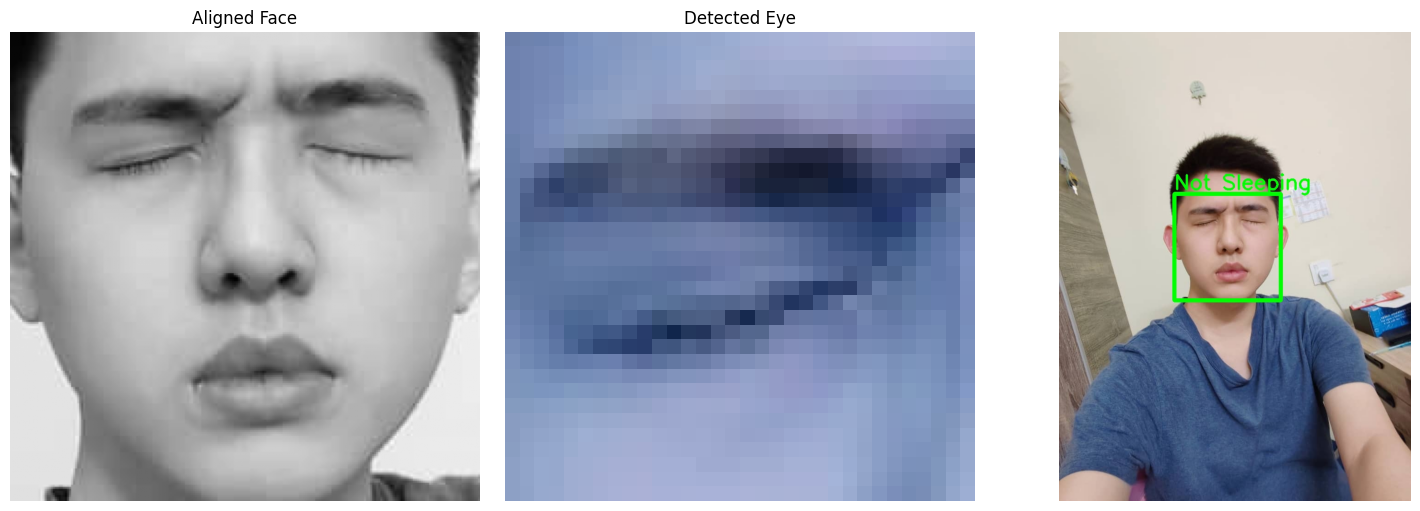

In [ ]:
figure = plt.figure(figsize=(15, 5))
predicted_image_path, aligned_face, confidence, detected_eyes = full_face_detection_pipeline('/content/sleepy2.jpg')

plt.subplot(1, 3, 1)
if aligned_face is not None:
    plt.imshow(aligned_face, cmap='gray')
    plt.title('Aligned Face')
    plt.axis('off')

plt.subplot(1, 3, 2)
if detected_eyes:
    plt.imshow(detected_eyes[0]) # Display the first detected eye
    plt.title('Detected Eye')
    plt.axis('off')
else:
    plt.text(0.5, 0.5, 'No eyes detected', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    plt.title('Detected Eye')
    plt.axis('off')


plt.subplot(1, 3, 3)
predicted_image = cv2.imread(predicted_image_path)
predicted_image = cv2.cvtColor(predicted_image, cv2.COLOR_BGR2RGB)
plt.imshow(predicted_image)
plt.axis('off')


plt.tight_layout()
plt.show()